# Installation PyPSA-Eur

This notebook walks through the full PyPSA-Eur workflow: setup, running the model, and analysing results from a solved sector-coupled network.

## Part 1 - Loading the network

### 1.1 Loading the network

Results are stored as NetCDF files under `pypsa-eur/results/networks/`.
The filename encodes the configuration: `base_s_***.nc`

In [1]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

n = pypsa.Network("pypsa-eur/resources/networks/base_s_1_elec.nc")
print(n)

INFO:pypsa.network.io:New version 1.4.0 available! (Current: 1.2.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, stores, sub_networks


PyPSA Network 'Unnamed Network'


# Conversion to GEMS format

## Part 2 - Imports & Logging

Firstly we import the Python package ; [pypsa-to-gems-converter](https://pypi.org/project/pypsa-to-gems-converter/)

In [2]:
import sys
import src as _pypsa_to_gems_converter_pkg
sys.modules.setdefault("pypsa_to_gems_converter", _pypsa_to_gems_converter_pkg)

from pypsa_to_gems_converter import PyPSAStudyConverter
import yaml
import logging
from pathlib import Path
import pypsa
from pypsa import Network
import importlib.metadata


# Configure logging so progress is visible in the notebook
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(name)s – %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("pypsa_to_gems")

study_dir = Path("tmp/my_study")  # Absolute path to the GEMS study directory

PyPSA_file_path = "pypsa-eur/resources/networks/base_s_1_elec.nc"  # Absolute path to the PyPSA file
network = Network(PyPSA_file_path)
print(network)  # Print the network to verify it loaded correctly

INFO:pypsa.network.io:New version 1.4.0 available! (Current: 1.2.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, stores, sub_networks


PyPSA Network 'Unnamed Network'


## Part 3 - Conversion PYPSA network to GEMS

In [ ]:
# Convert PyPSA network to GEMS
converter = PyPSAStudyConverter(
    pypsa_network=network,
    study_dir=study_dir,
    series_file_format=".tsv",  # Supported formats: .tsv, .csv
    solver_name="coin",  # Investment studies only support 'coin' and 'xpress'
).to_gems_study()

# pypsa-to-gems-converter 0.0.1 still emits the retired `nodes` and
# `area_connections` keys (both empty); GemsPy's SystemSchema forbids them.
system_yml = study_dir / "systems" / "input" / "system.yml"
_system = yaml.safe_load(system_yml.read_text())
for _legacy in ("nodes", "area_connections"):
    _system["system"].pop(_legacy, None)
system_yml.write_text(yaml.safe_dump(_system, sort_keys=False))

## Part 4 - Inspect the GEMS Study

In [4]:
import yaml
from collections import defaultdict

gems_study_file_path = Path(study_dir) / "systems" / "input"

system_yml_files = list(gems_study_file_path.rglob("system.yml"))
if not system_yml_files:
    print("system.yml not found.")
else:
    data = yaml.safe_load(system_yml_files[0].read_text())["system"]

    components = data.get("components", [])
    connections = data.get("connections", [])

    # Group components by model type
    by_model = defaultdict(list)
    for c in components:
        by_model[c["model"]].append(c["id"])

    print(f"System : {data['id']}")
    print(f"\nComponents ({len(components)} total)")
    print("-" * 20)
    for model, ids in sorted(by_model.items()):
        short = model.split(".")[-1]
        print(f"  [{short}]  ({len(ids)})")
        for cid in ids:
            print(f"    - {cid}")

    print(f"\nConnections ({len(connections)} total)")
    print("-" * 20)
    for conn in connections:
        print(f"  {conn.get('component1')}.{conn.get('port1')}  →  {conn.get('component2')}.{conn.get('port2')}")

System : Unnamed Network

Components (27 total)
--------------------
  [bus]  (3)
    - FR0_0
    - FR0_0_H2
    - FR0_0_battery
  [generator]  (15)
    - generator_FR0_0_CCGT
    - generator_FR0_0_biomass
    - generator_FR0_0_coal
    - generator_FR0_0_geothermal
    - generator_FR0_0_lignite
    - generator_FR0_0_nuclear
    - generator_FR0_0_oil
    - generator_FR0_0_waste
    - generator_FR0_0_0_offwind-float
    - generator_FR0_0_0_offwind-ac
    - generator_FR0_0_0_onwind
    - generator_FR0_0_0_solar-hsat
    - generator_FR0_0_0_solar
    - generator_FR0_0_0_offwind-dc
    - generator_FR0_0_ror
  [link]  (4)
    - link_FR0_0_H2_Electrolysis
    - link_FR0_0_H2_Fuel_Cell
    - link_FR0_0_battery_charger
    - link_FR0_0_battery_discharger
  [load]  (1)
    - load_FR0_0
  [storage_unit]  (2)
    - storage_unit_FR0_0_PHS
    - storage_unit_FR0_0_hydro
  [store]  (2)
    - store_FR0_0_H2
    - store_FR0_0_battery

Connections (28 total)
--------------------
  FR0_0.p_balance_port  

## Part 5 - Run the GEMS optimization

In this section, we use [GemsPy](https://gemspy.readthedocs.io/en/latest/) to run the GEMS converted simulation.

In [5]:
from gems_craft.study.folder import load_study
from gems_runner.session.session import SimulationSession
from gems_craft.optim_config.parsing import OptimConfig, TimeScopeConfig, ScenarioScopeConfig

n_timesteps = len(network.snapshots)

print("STUDY LOADING")
study = load_study(study_dir / "systems")
print("\tStudy loaded")

optim_config = OptimConfig(
    time_scope=TimeScopeConfig(first_time_step=0, last_time_step=n_timesteps - 1),
    scenario_scope=ScenarioScopeConfig(include=[0]),
)

print("\nSOLVING OPTIMIZATION PROBLEM")
result = SimulationSession(study=study, optim_config=optim_config).run()
print("\tOptimization problem solved")

STUDY LOADING
	Study loaded

SOLVING OPTIMIZATION PROBLEM


/home/gmaistre/Documents/GEMS/GEMS/pypsa_tuto_env/lib/python3.12/site-packages/gems_craft/model/resolve_library.py:175: UserWarning: Objective contribution 'operational_objective' has a scenario dimension but no explicit expec() operator. Expectation semantics (average over scenarios) are applied automatically. Add expec() explicitly to suppress this warning.
  _resolve_model(m, current_lib.port_types, current_lib.id)
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - solver_logs: False
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1655 primals, 2670 duals
Objective: 8.63e+07
Solver model: available
Solver message: Optimal



Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
Cols:           7 upper bounds greater than or equal to        1e+20 are treated as +Infinity
Rows:          15 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Rows:          15 upper bounds greater than or equal to        1e+20 are treated as +Infinity
ERROR:   getOptionIndex: Option "solver_logs" is unknown
LP has 2670 rows; 1655 cols; 7088 nonzeros
Coefficient ranges:
  Matrix  [4e-02, 9e+02]
  Cost    [1e-02, 2e+03]
  Bound   [2e+00, 8e+06]
  RHS     [3e+03, 7e+04]
Presolving model
1184 rows, 1387 cols, 3312 nonzeros 0s
704 rows, 1291 cols, 2736 nonzeros 0s
Dependent equations search running on 240 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
704 rows, 1195 cols, 2640 nonzeros 0s
Presolve reductions: rows 704(-1966); columns 1195(-460); nonzeros 2640(-4448) 
Solving the presolved LP
Using dual 

/home/gmaistre/Documents/GEMS/GEMS/pypsa_tuto_env/lib/python3.12/site-packages/linopy/common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
/home/gmaistre/Documents/GEMS/GEMS/pypsa_tuto_env/lib/python3.12/site-packages/linopy/common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
/home/gmaistre/Documents/GEMS/GEMS/pypsa_tuto_env/lib/python3.12/site-packages/linopy/common.py:492: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(


## Part 6 - Analyse the simulation results

The results are returned as a `SimulationTable` object by GemsPy.  
Below we extract the long-format DataFrame and visualise:
- the **objective value** (total system cost)
- the **installed capacity** (`p_nom`) per generator technology
- the **dispatch** (`p`) time series per technology

Objective value (total system cost): 86,300,015 €


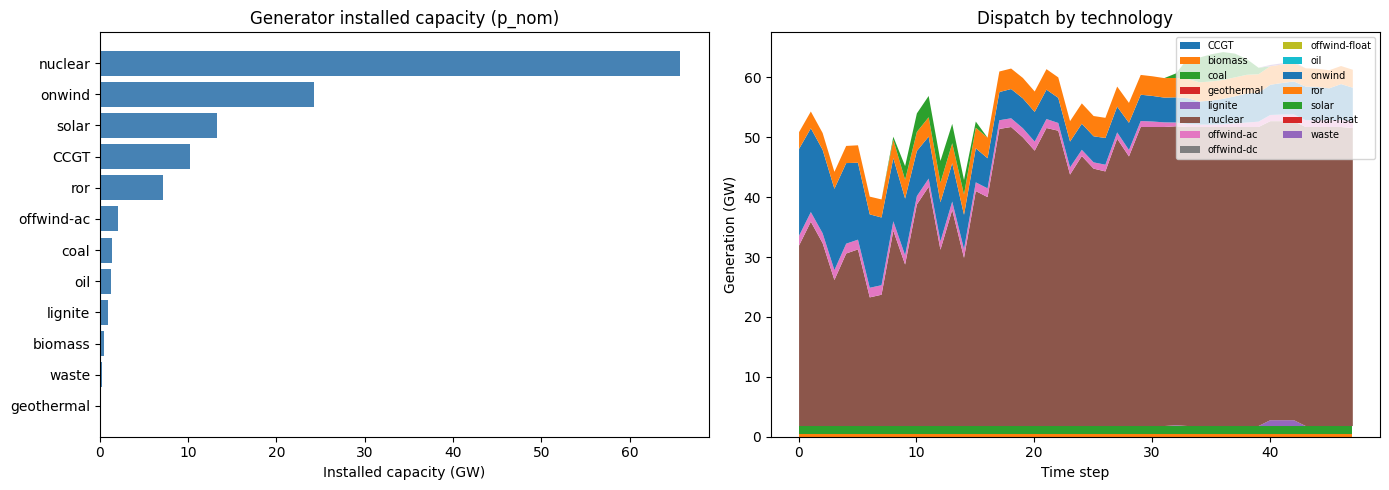

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = result.data

# ── Objective value ────────────────────────────────────────────────────────────
obj_row = df[df["output"] == "objective-value"]
if not obj_row.empty:
    obj_value = float(obj_row["value"].iloc[0])
    print(f"Objective value (total system cost): {obj_value:,.0f} €")

# ── Installed capacity (p_nom) per generator technology ───────────────────────
p_nom_df = df[
    (df["output"] == "p_nom") &
    (df["component"].str.startswith("generator_", na=False))
].copy()

p_nom_df["technology"] = p_nom_df["component"].str.split("_").str[-1]
capacity = p_nom_df.groupby("technology")["value"].sum().sort_values(ascending=False)
capacity = capacity[capacity > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(capacity.index, capacity.values / 1e3, color="steelblue")
axes[0].set_xlabel("Installed capacity (GW)")
axes[0].set_title("Generator installed capacity (p_nom)")
axes[0].invert_yaxis()

# ── Dispatch time series (p) per technology ───────────────────────────────────
p_df = df[
    (df["output"] == "p") &
    (df["component"].str.startswith("generator_", na=False)) &
    (df["absolute_time_index"].notna())
].copy()

p_df["technology"] = p_df["component"].str.split("_").str[-1]
p_df["t"] = pd.to_numeric(p_df["absolute_time_index"])

dispatch = (
    p_df.groupby(["t", "technology"])["value"]
    .sum()
    .unstack("technology")
    .fillna(0)
    .clip(lower=0)
)
dispatch = dispatch / 1e3

dispatch.plot.area(ax=axes[1], linewidth=0)
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Generation (GW)")
axes[1].set_title("Dispatch by technology")
axes[1].legend(loc="upper right", fontsize=7, ncol=2)

plt.tight_layout()
plt.show()